In [1]:
from __future__ import absolute_import, print_function

import argparse, json, os, requests, sys, time
from io import BytesIO
from os.path import join, isfile
from PIL import Image

from mxnet.gluon.model_zoo import vision
import numpy as np
from matplotlib import pyplot as plt

import tvm
from tvm import te
from tvm import rpc, autotvm, relay
from tvm.contrib import graph_runtime, utils, download
from tvm.contrib.debugger import debug_runtime
from tvm.relay import transform

import vta
from vta.testing import simulator
from vta.top import graph_pack

import torch
import torchvision
from tvm.contrib.download import download_testdata

from torch import nn
from torchvision import datasets, transforms


# Make sure that TVM was compiled with RPC=1
assert tvm.runtime.enabled("rpc")

/home/srchand/anaconda3/envs/tvm-build-il-2/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/srchand/anaconda3/envs/tvm-build-il-2/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE
  warn(f"Failed to load image Python extension: {e}")


In [2]:
# Load VTA parameters from the 3rdparty/vta-hw/config/vta_config.json file
env = vta.get_env()

# Set ``device=arm_cpu`` to run inference on the CPU
# or ``device=vta`` to run inference on the FPGA.
device = "vta"
target = env.target if device == "vta" else env.target_vta_cpu

# Dictionary lookup for when to start/end bit packing
pack_dict = {
    "resnet18_v1": ["nn.max_pool2d", "nn.global_avg_pool2d"],
    "resnet18": ["nn.max_pool2d", "nn.adaptive_avg_pool2d"],
    "resnet34": ["nn.max_pool2d", "nn.adaptive_avg_pool2d"],
    "resnet50": ["nn.max_pool2d", "nn.adaptive_avg_pool2d"],
    "resnet101": ["nn.max_pool2d", "nn.adaptive_avg_pool2d"],
    "vgg11": ["nn.max_pool2d", "nn.dense"],
    "vgg16":    ["nn.max_pool2d", "nn.dense"],
    "resnet34_v1": ["nn.max_pool2d", "nn.global_avg_pool2d"],
    "resnet18_v2": ["nn.max_pool2d", "nn.global_avg_pool2d"],
    "resnet34_v2": ["nn.max_pool2d", "nn.global_avg_pool2d"],
    "resnet50_v2": ["nn.max_pool2d", "nn.global_avg_pool2d"],
    "resnet101_v2": ["nn.max_pool2d", "nn.global_avg_pool2d"],
    "mobilenetv2_1.0": ["nn.max_pool2d", "nn.global_avg_pool2d"]
}

# Name of Gluon model to compile
# The ``start_pack`` and ``stop_pack`` labels indicate where
# to start and end the graph packing relay pass: in other words
# where to start and finish offloading to VTA.
#model = "resnet18_v1"
#assert model in pack_dict
model = "resnet18"

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class DynamicConv2D(nn.Module):
    def __init__ (self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super(DynamicConv2D, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        # self.dilation = dilation
        # self.groups = groups
        # self.bias = bias

        self.base_conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)

    # get active weights from the base_conv.
    # active_in_channels and active_out_channels are lists of tuples, where each tuple contains the start and end indices of the active channels.
    def get_active_weights(self, active_in_channels, active_out_channels):
        active_in_channels = [(0, self.in_channels)] if active_in_channels is None else active_in_channels
        active_out_channels = [(0, self.out_channels)] if active_out_channels is None else active_out_channels

        active_weights = self.base_conv.weight[active_out_channels[0][0]:active_out_channels[0][1], active_in_channels[0][0]:active_in_channels[0][1], :, :]
        return active_weights

    def forward(self, x, decompose_type):
        if decompose_type is None or decompose_type == 0:
            return self.base_conv(x)
        elif decompose_type == 1:
            # split the output channels into two groups
            active_out_channels = [(0, self.out_channels // 2), (self.out_channels // 2, self.out_channels)]
            active_in_channels = [(0, self.in_channels), (0, self.in_channels)]
            input_slice_indices = active_in_channels
        elif decompose_type == 2:
            # split the output channels into 4 groups
            active_out_channels = [(0, self.out_channels // 4), (self.out_channels // 4, self.out_channels // 2), (self.out_channels // 2, 3 * self.out_channels // 4), (3 * self.out_channels // 4, self.out_channels)]
            active_in_channels = [(0, self.in_channels), (0, self.in_channels), (0, self.in_channels), (0, self.in_channels)]
        elif decompose_type == 3:
            # split the input channels into two groups
            active_in_channels = [(0, self.in_channels // 2), (self.in_channels // 2, self.in_channels)]
            active_out_channels = [(0, self.out_channels), (0, self.out_channels)]
        elif decompose_type == 4:
            # split the input channels into 4 groups
            active_in_channels = [(0, self.in_channels // 4), (self.in_channels // 4, self.in_channels // 2), (self.in_channels // 2, 3 * self.in_channels // 4), (3 * self.in_channels // 4, self.in_channels)]
            active_out_channels = [(0, self.out_channels), (0, self.out_channels), (0, self.out_channels), (0, self.out_channels)]
        else:
            raise ValueError('Unknown decompose_type: {:}'.format(decompose_type))

        convs_completed = 0
        y = None
        for (i_x, i_y), (o_x, o_y) in zip(active_in_channels, active_out_channels):
            filters = self.get_active_weights([(i_x, i_y)], [(o_x, o_y)]).contiguous()
            x_slice = x[:, i_x:i_y, :, :]
            y_slice = F.conv2d(x_slice, filters, None, self.base_conv.stride, self.base_conv.padding, self.base_conv.dilation, self.base_conv.groups)

            if convs_completed == 0:
                y = y_slice
            elif decompose_type == 3 or decompose_type == 4:
                y = y + y_slice
            else:
                y = torch.cat((y, y_slice), 1)
            convs_completed += 1

        return y
    
class DynamicResidual(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, max_residual_depth=2, use_1x1_conv=False):
        super(DynamicResidual, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.max_residual_depth = max_residual_depth
        self.use_1x1_conv = use_1x1_conv

        self.convs = nn.ModuleList()

        for i in range(max_residual_depth):
            if i == 0:
                self.convs.append(DynamicConv2D(in_channels, out_channels, kernel_size, stride, padding))
            else:
                self.convs.append(DynamicConv2D(out_channels, out_channels, kernel_size, 1, padding))

        if self.use_1x1_conv:
            self.downsample = DynamicConv2D(in_channels, out_channels, 1, stride, 0)

        self.bns = nn.ModuleList(nn.BatchNorm2d(out_channels) for i in range(max_residual_depth))
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, depth, decomp_type_list, downsample_decomp_type=0):
        if depth == 0:
            # just pass the input through
            return x

        residual = x
        for i in range(depth):
            residual = self.convs[i](residual, decomp_type_list[i])
            residual = self.bns[i](residual)
            if i < depth - 1:
                residual = self.relu(residual)

        if self.use_1x1_conv:
            x = self.downsample(x, downsample_decomp_type)

        return self.relu(x + residual)

    
RESNET_FILTERS = [64, 128, 256, 512, 1024, 2048]
class OFADynamicResnet(nn.Module):
    def __init__(self, num_blocks=4, max_block_depth=4, max_residual_depth=2, num_classes=10):
        super(OFADynamicResnet, self).__init__()
        self.num_blocks = num_blocks
        self.max_residual_depth = max_residual_depth
        self.num_classes = num_classes
        self.max_block_depth = max_block_depth
        self.max_num_residuals_per_block = math.ceil(self.max_block_depth / self.max_residual_depth)

        # first layer of resnet includes 7x7 convolution, batchnorm, relu and maxpool
        self.first_layer = nn.Sequential(nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(inplace=True),
                                         nn.MaxPool2d(kernel_size=2, stride=2, padding=0))

        # last layer of resnet includes adaptive avgpool, flatten and linear layer
        self.last_layer = nn.Sequential(nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
                                        nn.Linear(RESNET_FILTERS[num_blocks - 1], num_classes))

        self.resnet_blocks = self.get_resnet_blocks()

        self.default_arch = self.default_arch()

        self.sampled_arch = None


    def get_resnet_blocks(self):
        blocks = nn.ModuleList()
        for i in range(self.num_blocks):
            in_channels = RESNET_FILTERS[i] if i == 0 else RESNET_FILTERS[i - 1]
            out_channels = RESNET_FILTERS[i] if i == 0 else RESNET_FILTERS[i]
            stride = 1 if i == 0 else 2
            blocks.append(ResNetBlock(in_channels, out_channels, 3, stride, 1, self.max_residual_depth, self.max_block_depth, i > 0))
        return blocks

    def default_arch(self):
        # residual depth list is number of convs in each residual block. for example, if max_residual_depth=2,
        # and max_block_depth=4, and num_blocks = 4, then residual_depth_list=[[2, 2], [2, 2], [2, 2], [2, 2]]
        # default decomp_type_list will be [[[0,0], [0,0]], [[0,0], [0,0]], [[0,0], [0,0]], [[0,0], [0,0]]] since there are only 2 convs in each residual block.
        # default downsample_decomp_type_list will be [0, 0, 0] since there are only 3 downsample convs.

        arch = {"residual_depth_list": [], "decomp_type_list": [], "downsample_decomp_type_list": []}
        for i in range(self.num_blocks):
            arch["residual_depth_list"].append([])
            arch["decomp_type_list"].append([])
            for j in range(self.max_num_residuals_per_block):
                arch["decomp_type_list"][i].append([])
                arch["residual_depth_list"][i].append(self.max_residual_depth)
                for k in range(self.max_residual_depth):
                    arch["decomp_type_list"][i][j].append(0)

        arch["downsample_decomp_type_list"] = [0] * (self.num_blocks - 1)

        return arch

    def sample_arch(self):
        # sample residual depth list, decomp_type_list and downsample_decomp_type_list
        # rules:
        arch = {"residual_depth_list": [], "decomp_type_list": [], "downsample_decomp_type_list": []}
        for i in range(self.num_blocks):
            arch["residual_depth_list"].append([])
            arch["decomp_type_list"].append([])
            for j in range(self.max_num_residuals_per_block):
                arch["decomp_type_list"][i].append([])
                if j == 0:
                    # first residual block of each block needs to have a depth of at least 1.
                    arch["residual_depth_list"][i].append(np.random.randint(1, self.max_residual_depth + 1))
                else:
                    arch["residual_depth_list"][i].append(np.random.randint(0, self.max_residual_depth + 1))
                for k in range(self.max_residual_depth):
                    arch["decomp_type_list"][i][j].append(np.random.randint(0, 5))
        arch["downsample_decomp_type_list"] = np.random.randint(0, 5, self.num_blocks - 1)

        return arch

    def set_active_subnet(self, arch):
        self.sampled_arch = arch

    def get_active_subnet(self):
        return self.sampled_arch if self.sampled_arch is not None else self.default_arch

    def forward(self, x):
        if self.sampled_arch is None:
            arch = self.default_arch
        else:
            arch = self.sampled_arch

        x = x.reshape(-1, 3, 224, 224)
        x = self.first_layer(x)
        for i in range(self.num_blocks):
            if i == 0:
                x = self.resnet_blocks[i](x, arch["residual_depth_list"][i], arch["decomp_type_list"][i], 0)
            else:
                x = self.resnet_blocks[i](x, arch["residual_depth_list"][i], arch["decomp_type_list"][i], arch["downsample_decomp_type_list"][i-1])

        x = self.last_layer(x)



        return x

class ResNetBlock(nn.Module):
    def __init__(self, in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, max_residual_depth=2, max_block_depth=4, use_1x1_conv=False):
        super(ResNetBlock, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.max_residual_depth = max_residual_depth
        self.use_1x1_conv = use_1x1_conv
        self.max_block_depth = max_block_depth

        self.num_residuals = math.ceil(self.max_block_depth/self.max_residual_depth)
        self.residuals = nn.ModuleList()

        for i in range(self.num_residuals):
            if i == 0:
                self.residuals.append(DynamicResidual(in_channels, out_channels, kernel_size, stride, padding, max_residual_depth, use_1x1_conv))
            else:
                self.residuals.append(DynamicResidual(out_channels, out_channels, kernel_size, 1, padding, max_residual_depth, False))


    def forward(self, x, residual_depth_list, decomp_type_list, downsample_decomp_type):
        for i in range(self.num_residuals):
            x = self.residuals[i](x, residual_depth_list[i], decomp_type_list[i], downsample_decomp_type)
        return x

In [4]:
from torchinfo import summary

net = OFADynamicResnet()

state_dict = torch.load("/mnt/hgfs/vmware_ubuntu_sf/OFA_networks/checkpoint.pth")
net.load_state_dict(state_dict)

summary(net, input_size=(1, 3, 224, 224))


Layer (type:depth-idx)                             Output Shape              Param #
OFADynamicResnet                                   [1, 10]                   --
├─Sequential: 1-1                                  [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                                 [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                            [1, 64, 112, 112]         128
│    └─ReLU: 2-3                                   [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                              [1, 64, 56, 56]           --
├─ModuleList: 1-2                                  --                        --
│    └─ResNetBlock: 2-5                            [1, 64, 56, 56]           --
│    │    └─ModuleList: 3-1                        --                        148,224
│    └─ResNetBlock: 2-6                            [1, 128, 28, 28]          --
│    │    └─ModuleList: 3-2                        --                        525,952
│    └─ResNetBlock: 2

In [5]:
arch = net.sample_arch()
net.set_active_subnet(arch)
summary(net, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                             Output Shape              Param #
OFADynamicResnet                                   [1, 10]                   --
├─Sequential: 1-1                                  [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                                 [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                            [1, 64, 112, 112]         128
│    └─ReLU: 2-3                                   [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                              [1, 64, 56, 56]           --
├─ModuleList: 1-2                                  --                        --
│    └─ResNetBlock: 2-5                            [1, 64, 56, 56]           --
│    │    └─ModuleList: 3-1                        --                        148,224
│    └─ResNetBlock: 2-6                            [1, 128, 28, 28]          --
│    │    └─ModuleList: 3-2                        --                        525,952
│    └─ResNetBlock: 2

In [ ]:
net.get_active_subnet()

In [6]:
remote = None
if env.TARGET not in ["sim", "tsim", "intelfocl"]:

    # Get remote from tracker node if environment variable is set.
    # To set up the tracker, you'll need to follow the "Auto-tuning
    # a convolutional network for VTA" tutorial.
    tracker_host = os.environ.get("TVM_TRACKER_HOST", None)
    tracker_port = os.environ.get("TVM_TRACKER_PORT", None)
    # Otherwise if you have a device you want to program directly from
    # the host, make sure you've set the variables below to the IP of
    # your board.
#     device_host = os.environ.get("VTA_RPC_HOST", "192.168.2.99")
    device_host="10.42.0.188"
#     device_host="10.100.86.111"
    device_port = os.environ.get("VTA_RPC_PORT", "9091")
    if not tracker_host or not tracker_port:
        remote = rpc.connect(device_host, int(device_port))
    else:
        remote = autotvm.measure.request_remote(
            env.TARGET, tracker_host, int(tracker_port), timeout=10000
        )

    # Reconfigure the JIT runtime and FPGA.
    # You can program the FPGA with your own custom bitstream
    # by passing the path to the bitstream file instead of None.
    reconfig_start = time.time()
    vta.reconfig_runtime(remote)

#     vta.program_fpga(remote, bitstream="/mnt/hgfs/vmware_ubuntu_sf/bitstreams/vta_pynq_sniffer_reset_on_read.bit")
#     vta.program_fpga(remote, bitstream='/mnt/hgfs/vmware_ubuntu_sf/vta_4x8x8/vta_new_1x16x16_memory_trojan_runtime_sampling.bit')
#     vta.program_fpga(remote, bitstream='/mnt/hgfs/vmware_ubuntu_sf/vta_4x8x8/vta_1x16x16_acc_18_memory_trojan_runtime_sampling.bit')
    reconfig_time = time.time() - reconfig_start
    print("Reconfigured FPGA and RPC runtime in {0:.2f}s!".format(reconfig_time))

# In simulation mode, host the RPC server locally.
else:
    remote = rpc.LocalSession()

    if env.TARGET in ["intelfocl"]:
        # program intelfocl aocx
        vta.program_fpga(remote, bitstream="vta.bitstream")

# Get execution context from remote
ctx = remote.ext_dev(0) if device == "vta" else remote.cpu(0)

Reconfigured FPGA and RPC runtime in 0.02s!


In [7]:
import glob
# schedule_log_files = glob.glob(r'../logs/tuning_logs/vta_1x16x16_pynq_arm/*.log')
schedule_log_files = glob.glob(r'../logs/tuning_logs/vta_1x16x16/*.log')
# schedule_log_files = glob.glob(r'/home/srchand/Desktop/research/neurobfuscator/seq_obfuscator/obf_tmp_file/autotvm_model_10_obf_pruned.log')

# schedule_log_files = glob.glob(r'../logs/tuning_logs/*.log')


In [8]:
# Load pre-configured AutoTVM schedules
with autotvm.tophub.context(target, extra_files=schedule_log_files):
# with autotvm.tophub.context(target):

    
    input_name = "input0"

    # Populate the shape and data type dictionary for ImageNet classifier input
    dtype_dict = {input_name: "float32"}
    shape_dict = {input_name: (env.BATCH, 3, 224, 224)}


#     # Get off the shelf gluon model, and convert to relay
#     gluon_model = vision.get_model(model, pretrained=True)
    
    
#     pytorch_model = getattr(torchvision.models, model)(pretrained=True).eval()
    pytorch_model = net
#     pytorch_model.eval()
    
        
    input_shape = [env.BATCH, 3, 224, 224]
    input_data = torch.randn(input_shape)
    scripted_model = torch.jit.trace(pytorch_model, input_data)
    
    shape_list = [(input_name, input_shape)]


    # Measure build start time
    build_start = time.time()

#     Start front end compilation
    mod, params = relay.frontend.from_pytorch(scripted_model, shape_list)
    
    
#     mod, params = relay.frontend.from_mxnet(gluon_model, shape_dict)

#     #mod, params = relay.frontend.from_mxnet(net, shape_dict)
    
#     # Update shape and type dictionary
    shape_dict.update({k: v.shape for k, v in params.items()})
    dtype_dict.update({k: str(v.dtype) for k, v in params.items()})
    

    if target.device_name == "vta":
        # Perform quantization in Relay
        # Note: We set opt_level to 3 in order to fold batch norm
        with tvm.transform.PassContext(opt_level=3):
            with relay.quantize.qconfig(global_scale=8.0, skip_conv_layers=[0]):
                mod = relay.quantize.quantize(mod, params=params)
#                 print(mod.astext(show_meta_data=False))
#                 print(apput)
            # Perform graph packing and constant folding for VTA target
            assert env.BLOCK_IN == env.BLOCK_OUT
            # do device annotation if target is intelfocl or sim
            relay_prog = graph_pack(
                mod["main"],
                env.BATCH,
                env.BLOCK_IN,
                env.BLOCK_OUT,
                env.WGT_WIDTH,
                start_name=pack_dict[model][0],
#                 stop_name='cast',
#                 stop_name_idx=114,
                stop_name=pack_dict[model][1],
#                 start_name='nn.relu',
#                 start_name_idx=2,
#                 stop_name='nn.adaptive_avg_pool2d',
#                 start_name="cast",
#                 start_name_idx=8,
#                 stop_name="cast",                
#                 stop_name_idx=71,
                device_annot=(env.TARGET == "intelfocl"),
            )
    else:
        relay_prog = mod["main"]

    # Compile Relay program with AlterOpLayout disabled
    if target.device_name != "vta":
        with tvm.transform.PassContext(opt_level=3, disabled_pass={"AlterOpLayout"}):
            graph, lib, params = relay.build(
                relay_prog, target=target, params=params, target_host=env.target_host
            )
    else:
        if env.TARGET == "intelfocl":
            # multiple targets to run both on cpu and vta
            target = {"cpu": env.target_vta_cpu, "ext_dev": target}
        with vta.build_config(opt_level=3, disabled_pass={"AlterOpLayout"}):
            graph, lib, params = relay.build(
                relay_prog, target=target, params=params, target_host=env.target_host
            )

    # Measure Relay build time
    build_time = time.time() - build_start
    print(model + " inference graph built in {0:.2f}s!".format(build_time))

    # Send the inference library over to the remote RPC server
    temp = utils.tempdir()
    lib.export_library(temp.relpath("graphlib.tar"))
    remote.upload(temp.relpath("graphlib.tar"))
    lib = remote.load_module("graphlib.tar")

    if env.TARGET == "intelfocl":
        ctxes = [remote.ext_dev(0), remote.cpu(0)]
        m = graph_runtime.create(graph, lib, ctxes)
    else:
        # Graph runtime
        m = graph_runtime.create(graph, lib, ctx)

Cannot find config for target=ext_dev -keys=vta,cpu -device=vta -model=zcu104_1x16x16_i8w8a32_15_15_18_17, workload=('dense_pack.x86', ('TENSOR', (1, 512), 'float32'), ('TENSOR', (10, 512), 'float32'), None, 'float32'). A fallback configuration is used, which may bring great performance regression.
/tmp/ipykernel_13831/2877555350.py:89: DeprecationWarning: legacy graph runtime behavior of producing json / lib / params will be removed in the next release. Please see documents of tvm.contrib.graph_runtime.GraphModule for the  new recommended usage.
  graph, lib, params = relay.build(


resnet18 inference graph built in 27.82s!


In [ ]:
print(mod.astext(show_meta_data=False))

In [9]:

img_transforms = transforms.Compose([
            transforms.ToTensor(),
        ])

imagenette_classes = "ImageNette_Images/imagenette_classes.txt"
imagenette = eval(open(imagenette_classes).read())


imagenette_image = [
    "ImageNette_Images/images/original/tench.JPEG",
    "ImageNette_Images/images/original/english_springer.JPEG",
    "ImageNette_Images/images/original/cassette_player.JPEG",
    "ImageNette_Images/images/original/chainsaw.JPEG",
    "ImageNette_Images/images/original/church.JPEG",
    "ImageNette_Images/images/original/french_horn.JPEG",
    "ImageNette_Images/images/original/garbage_truck.JPEG",
    "ImageNette_Images/images/original/gas_pump.JPEG",
    "ImageNette_Images/images/original/golf_ball.JPEG",
    "ImageNette_Images/images/original/parachute.JPEG",
]

def load_images_and_run(idx):
    image = Image.open(imagenette_image[idx]).resize((224,224))
    plt.imshow(image)
    plt.show()
    image = np.array(image) - np.array([123.0, 117.0, 104.0])
    image /= np.array([58.395, 57.12, 57.375])

    image = image.transpose((2, 0, 1))
#     image = img_transforms(image).numpy()

    image = image[np.newaxis, :]
    image = np.repeat(image, env.BATCH, axis=0)

    # Set the network parameters and inputs
    m.set_input(**params)
    m.set_input(input_name, image)
    
    m.run()
    
    tvm_output = m.get_output(0, tvm.nd.empty((env.BATCH, 10), "float32", remote.cpu(0)))
    for b in range(env.BATCH):
        top_categories = np.argsort(tvm_output.asnumpy()[b])
        # Report top-5 classification results
        print("\n{} prediction for sample {}".format(model, b))
        print("\t#1:", imagenette[top_categories[-1]])
        print("\t#2:", imagenette[top_categories[-2]])
        print("\t#3:", imagenette[top_categories[-3]])
        print("\t#4:", imagenette[top_categories[-4]])
        print("\t#5:", imagenette[top_categories[-5]])
        # This just checks that one of the 5 top categories
        # is one variety of cat; this is by no means an accurate
        # assessment of how quantization affects classification
        # accuracy but is meant to catch changes to the
        # quantization pass that would accuracy in the CI.
        detected = False
        for k in top_categories[-5:]:
            if imagenette[idx] in imagenette[k]:
                detected = True
        assert detected

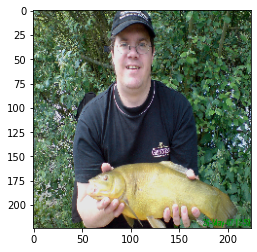


resnet18 prediction for sample 0
	#1: gas pump
	#2: tench
	#3: chain saw
	#4: English springer
	#5: parachute


In [11]:
for i in range(1):
    load_images_and_run(i)